In [ ]:
# 📦 Libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

# 📁 Files
from google.colab import files
uploaded = files.upload()

# 📄 Read files
df_taxa = pd.read_csv("FW_lagoon - food web by sampling.csv", header=None)
df_links_raw = pd.read_csv("FW_lagoon - trophic links.csv")
df_links = df_links_raw.rename(columns={"consumer": "target", "resource": "source"})

In [ ]:
# 🎨 Functional groups and nodes
grupo_nodo = {
    "DOM": "detritus", "FPOM": "detritus", "CPOM": "detritus",
    "Bacterioplankton": "microbial heterotroph", "Periphyton": "periphyton",
    "Copepod": "consumer", "Hirudinea": "macroinvertebrate", "Oligochaeta": "macroinvertebrate",
    "Ampullariidae": "macroinvertebrate", "Sphaeriidae": "macroinvertebrate", "Cochliopidae": "macroinvertebrate",
    "Chironomidae": "macroinvertebrate", "Hyriidae": "macroinvertebrate",
    "Hydrophilidae_larvae": "macroinvertebrate", "Hydrophilidae_adult": "macroinvertebrate",
    "Belostomatidae": "macroinvertebrate", "Mycetopodidae": "macroinvertebrate",
    "Corbiculidae": "macroinvertebrate", "Corixidae": "macroinvertebrate",
    "Ancylini": "macroinvertebrate", "Hyalellidae": "macroinvertebrate", "Palaemonidae": "macroinvertebrate",
    "Planorbidae": "macroinvertebrate", "Physidae": "macroinvertebrate",
    "Prochilodus_lineatus": "fish", "Astyanax_sp": "fish", "Hypostomus_commersoni": "fish",
    "Trachemys_dorbigni_juvenile": "aquatic reptile", "Trachemys_dorbigni_adult": "aquatic reptile",
    "Phrynops_hilarii": "aquatic reptile"
}

fitos = [  # phytoplankton
    "Pediastrum", "Chlorella", "Scenedesmus", "Coelastrum", "Closterium", "Mougeotia", "Cosmarium",
    "Dyctiosphaerium", "Staurastrum", "Eudorina", "Tetrastrum", "Schroederia", "Tetraedron", "Sphaerocystis",
    "Staurodesmus", "Ankyra", "Crucigenia", "Phacus", "Euglena", "Trachelomonas", "Strombomonas", "Lepocinclis",
    "Colacium", "Navícula", "Gomphonema", "Amphipleura", "Fragilaria", "Nitzschia", "Sellaphora", "Pinnularia",
    "Aulacoseira", "Reimeria", "Cymbella", "Gomphoneis", "Hantzschia", "Geissleria", "Surirella", "Diatoma",
    "Cyclotella", "Caloneis", "Gyrosigma", "Diploneis", "Ceratium", "Gymnodinium", "Spirulina", "Merismopedia",
    "Aphanocapsa", "Chroocuccus", "Dolichospermum", "Pseudoanabaena", "Microcystis"
]
for f in fitos:
    grupo_nodo[f] = "phytoplankton"

color_nodo = {
    "detritus": "saddlebrown",
    "microbial heterotroph": "goldenrod",
    "periphyton": "seagreen",
    "consumer": "skyblue",
    "phytoplankton": "lightgreen",
    "macroinvertebrate": "moccasin",
    "fish": "lightcoral",
    "aquatic reptile": "lightgray"
}

label_alias = {
    "Bacterioplankton": "BP", "Pseudoanabaena": "P_anabaena", "Hydrophilidae_larvae": "HL",
    "Hydrophilidae_adult": "HA", "Prochilodus_lineatus": "Prochilodus",
    "Hypostomus_commersoni": "Hypostomus", "Trachemys_dorbigni_juvenile": "Trachemys_J",
    "Trachemys_dorbigni_adult": "Trachemys_A", "Phrynops_hilarii": "Phrynops"
}

# 🔄 Analysis and visualization
os.makedirs("outputs/figs", exist_ok=True)
metricas = []

for col in df_taxa.columns[9:-1]:  # Omite the first 9 columns and the last one
    fecha = df_taxa.iloc[0, col]
    fecha_str = str(fecha).replace("/", "-")
    presentes = df_taxa.iloc[1:, col].dropna().unique().tolist()

    sub_links = df_links[df_links["source"].isin(presentes) & df_links["target"].isin(presentes)]
    G = nx.DiGraph()
    G.add_edges_from(zip(sub_links["source"], sub_links["target"]))

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)
    colores = [color_nodo.get(grupo_nodo.get(n, ""), "gray") for n in G.nodes()]
    etiquetas = {n: label_alias.get(n, n) for n in G.nodes()}

    nx.draw_networkx_nodes(G, pos, node_color=colores, node_size=800)
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_labels(G, pos, labels=etiquetas, font_size=7)

    plt.title(f"Red trófica - {fecha}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"outputs/figs/foodweb_{fecha_str}.png")
    plt.close()

    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    conectancia = num_edges / (num_nodes * (num_nodes - 1)) if num_nodes > 1 else 0
    densidad = nx.density(G)
    grado_medio = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
    componentes = nx.number_weakly_connected_components(G)

    metricas.append({
        "fecha": fecha,
        "nodos": num_nodes,
        "enlaces": num_edges,
        "conectancia": round(conectancia, 4),
        "densidad": round(densidad, 4),
        "grado_medio": round(grado_medio, 2),
        "componentes": componentes
    })

# 📤 Export metrics
df_out = pd.DataFrame(metricas)
df_out.to_csv("outputs/metrics_by_date.csv", index=False)
df_out.head()

Saving FW_lagoon - food web by sampling.csv to FW_lagoon - food web by sampling (1).csv
Saving FW_lagoon - trophic links.csv to FW_lagoon - trophic links (1).csv


,fecha,nodos,enlaces,conectancia,densidad,grado_medio,componentes
0,14/05/2016,28,44,0.0582,0.0582,3.14,1
1,09/07/2016,33,77,0.0729,0.0729,4.67,1
2,10/09/2016,33,112,0.1061,0.1061,6.79,1
3,20/01/2017,37,127,0.0953,0.0953,6.86,1
4,16/03/2017,29,52,0.0640,0.0640,3.59,1


🔎 Métricas de red por muestreo


,fecha,nodos,enlaces,conectancia,densidad,grado_medio,componentes
0,14/05/2016,28,44,0.0582,0.0582,3.14,1
1,09/07/2016,33,77,0.0729,0.0729,4.67,1
2,10/09/2016,33,112,0.1061,0.1061,6.79,1
3,20/01/2017,37,127,0.0953,0.0953,6.86,1
4,16/03/2017,29,52,0.0640,0.0640,3.59,1
5,06/04/2017,37,88,0.0661,0.0661,4.76,1
6,29/06/2017,22,40,0.0866,0.0866,3.64,1
7,08/09/2017,22,41,0.0887,0.0887,3.73,1
8,15/11/2017,23,54,0.1067,0.1067,4.70,1
9,23/12/2017,25,54,0.0900,0.0900,4.32,1


📌 foodweb_01-06-2019.png


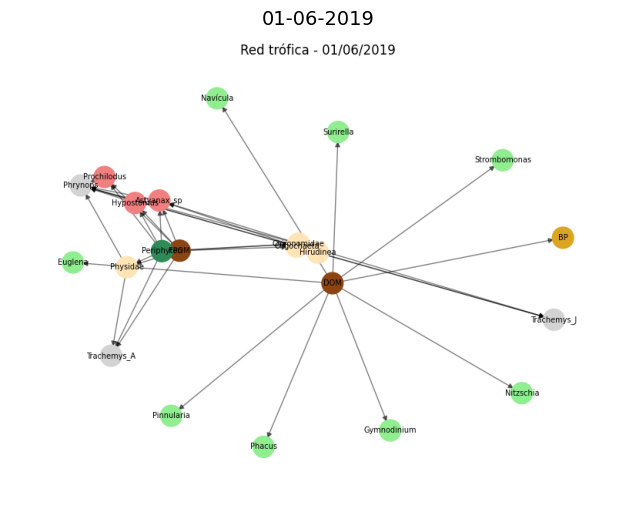

📌 foodweb_06-04-2017.png


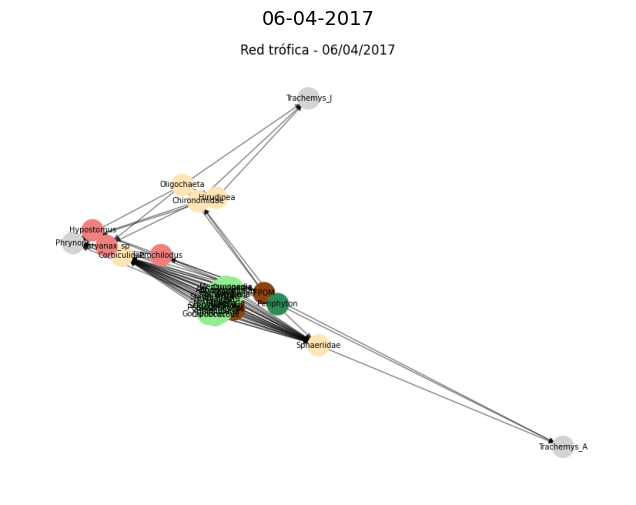

📌 foodweb_08-09-2017.png


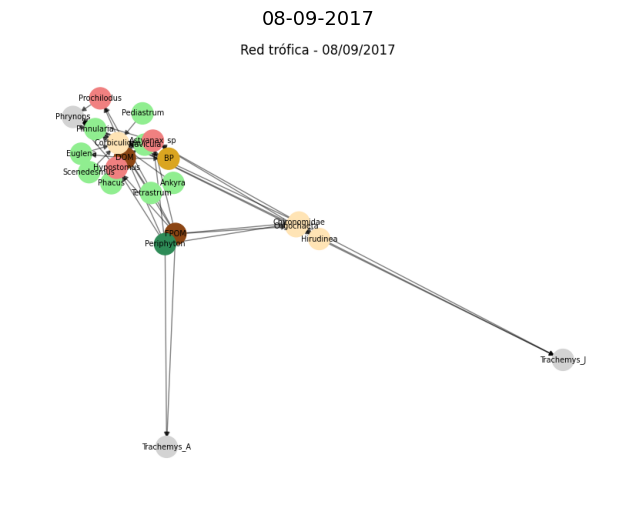

📌 foodweb_09-03-2019.png


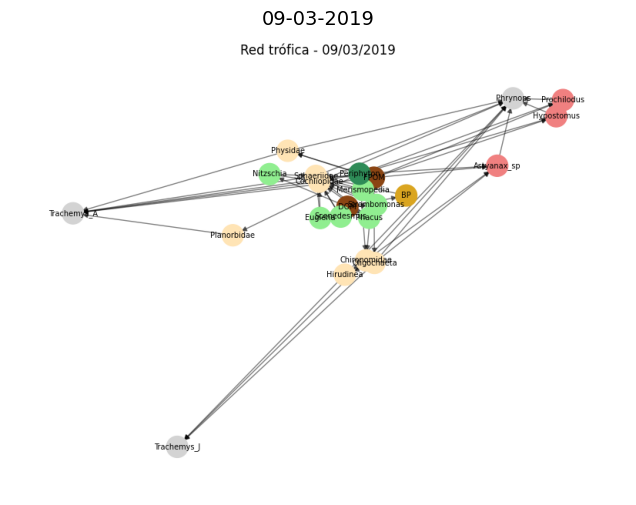

📌 foodweb_09-07-2016.png


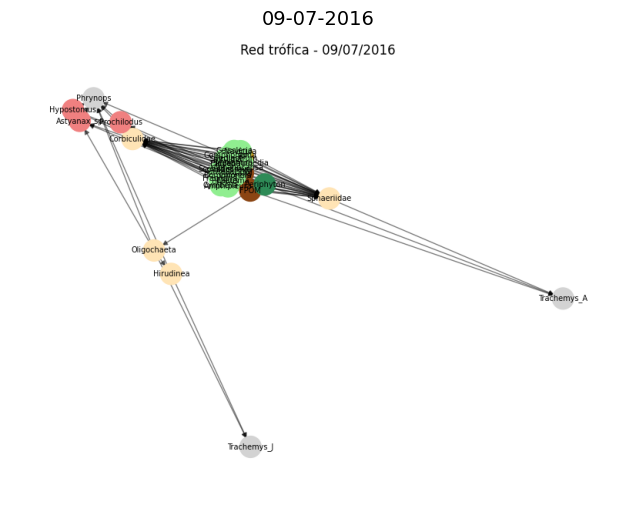

📌 foodweb_10-09-2016.png


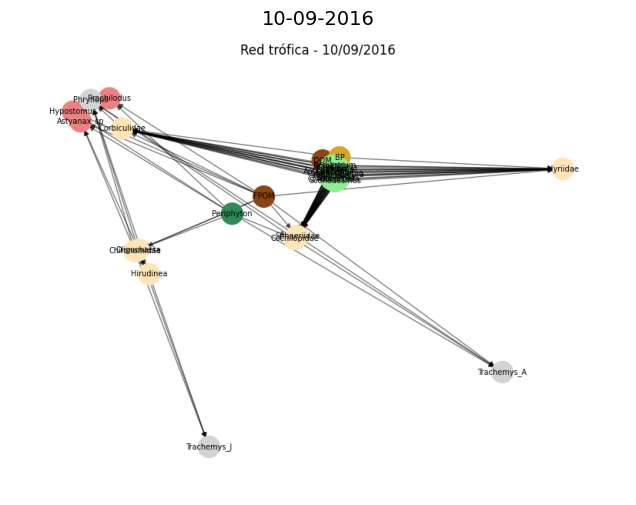

📌 foodweb_11-08-2018.png


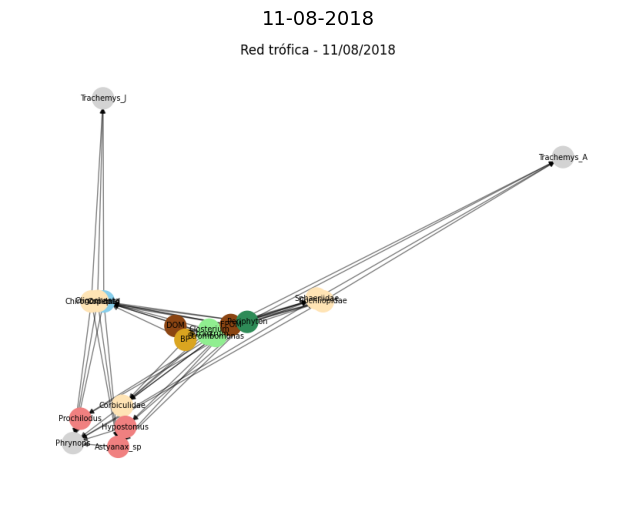

📌 foodweb_14-05-2016.png


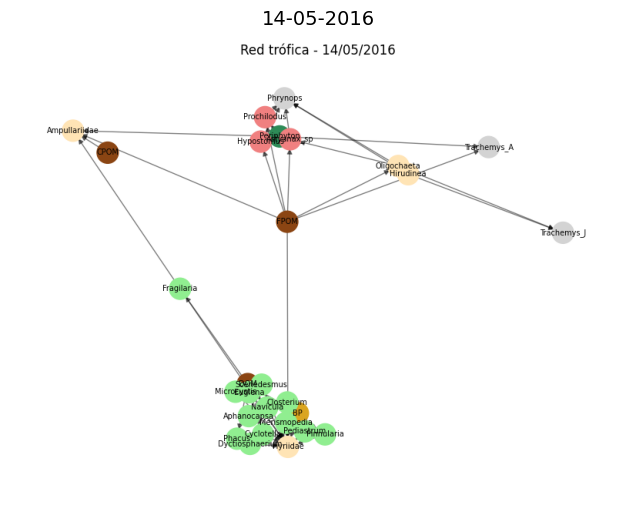

📌 foodweb_15-11-2017.png


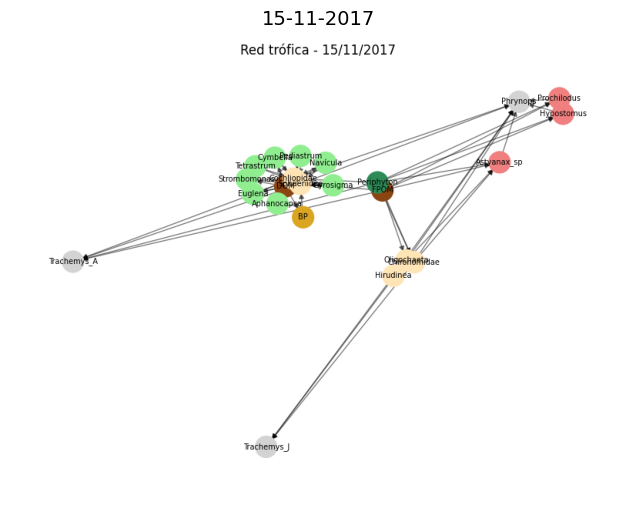

📌 foodweb_16-03-2017.png


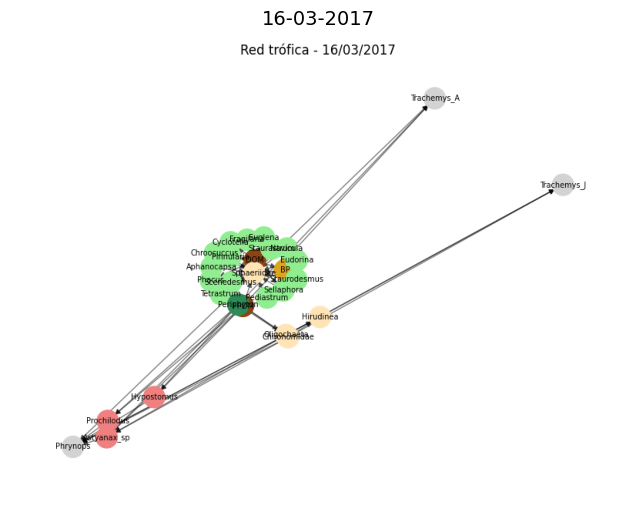

📌 foodweb_19-05-2018.png


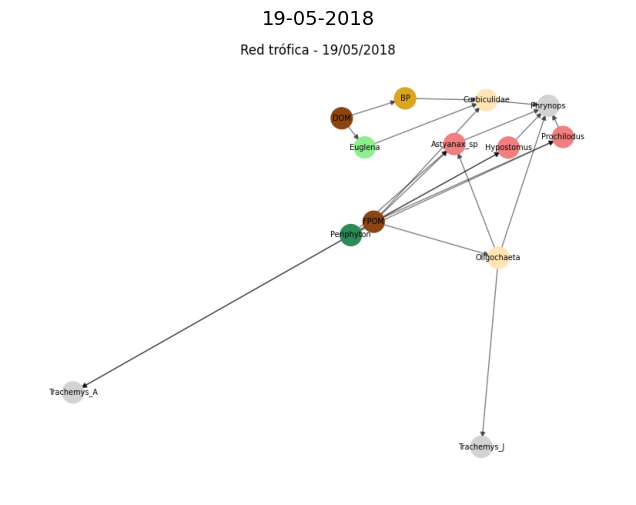

📌 foodweb_20-01-2017.png


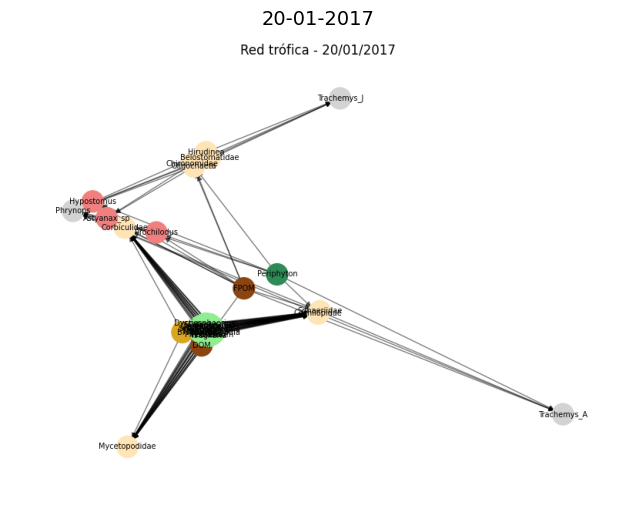

📌 foodweb_20-10-2018.png


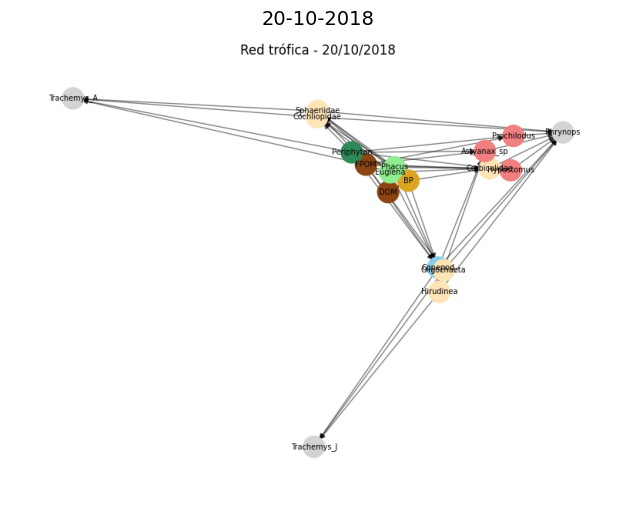

📌 foodweb_23-02-2018.png


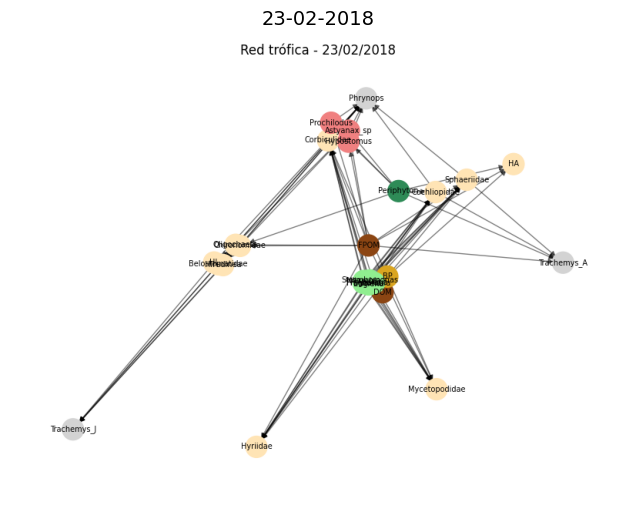

📌 foodweb_23-12-2017.png


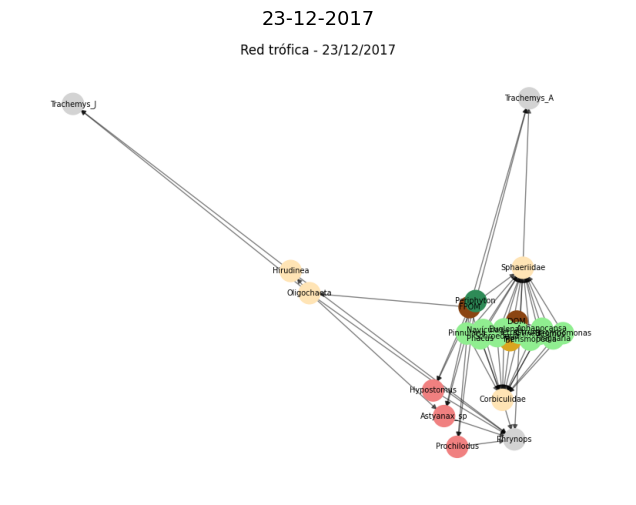

📌 foodweb_29-06-2017.png


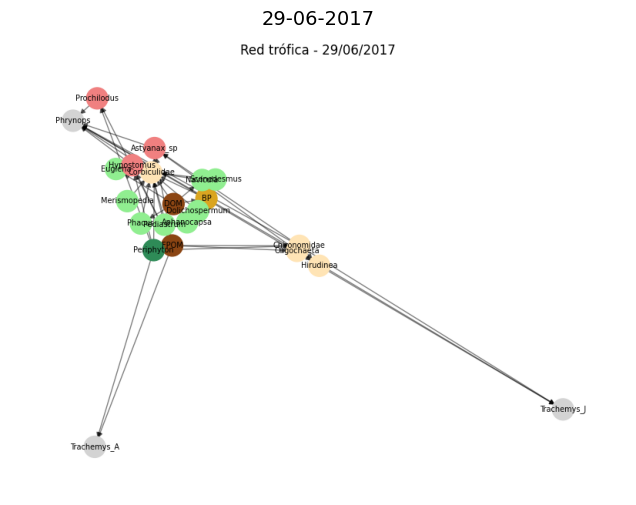

In [ ]:
# 📊 Show metric table
df_metr = pd.read_csv("outputs/metrics_by_date.csv")
print("🔎 Métricas de red por muestreo")
display(df_metr)

# 🖼️ Show graphs
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os

img_files = sorted([f for f in os.listdir("outputs/figs") if f.endswith(".png")])

for img in img_files:
    print(f"📌 {img}")
    img_path = os.path.join("outputs/figs", img)
    img_data = mpimg.imread(img_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_data)
    plt.axis('off')
    plt.title(img.replace("foodweb_", "").replace(".png", ""), fontsize=14)
    plt.show()